# 3-D segmentation — train / val / test

Processes the full `(H, D, W)` volume with a **3-D DynUNet**.  
Training samples random `PATCH_SIZE` crops biased toward foreground (clasts are only ~2 % of voxels).  
Split is a contiguous slice range along the H axis so every 3-D patch drawn during training is self-consistent.

In [1]:
import os, subprocess

def _best_gpu():
    """Pick the GPU with the most free memory via nvidia-smi."""
    out = subprocess.run(
        ["nvidia-smi", "--query-gpu=memory.free", "--format=csv,nounits,noheader"],
        capture_output=True, text=True,
    ).stdout.strip().split("\n")
    free = [int(x) for x in out]
    idx  = free.index(max(free))
    print(f"GPU selected: {idx}  ({free[idx]} MiB free)  all: {free}")
    return idx

os.environ["CUDA_VISIBLE_DEVICES"] = str(_best_gpu())

import numpy as np
import torch
import matplotlib.pyplot as plt
import monai
import nibabel as nib
from monai.data import DataLoader, Dataset
from monai.inferers import sliding_window_inference
from pathlib import Path
from monai.networks.nets import DynUNet
from scipy.ndimage import binary_dilation
from time import perf_counter as time

GPU selected: 0  (35330 MiB free)  all: [35330, 29350]


## 1. Data

In [ ]:
IMAGE_NII = Path("/work3/killeg/data/xray_1.nii") #Path("/zhome/d8/d/230907/me/meteorite/data/xray_2.nii")
SEG_NII   = Path("/zhome/d8/d/230907/me/meteorite/masks/ROI_total.nii.gz")

img_vol = nib.load(IMAGE_NII).get_fdata().astype(np.float32)
seg_vol = nib.load(SEG_NII).get_fdata()

img_vol    = (img_vol - img_vol.min()) / (img_vol.max() - img_vol.min())
binary_seg = np.isin(seg_vol, [1, 2, 3]).astype(np.float32)
roi_mask   = binary_dilation(seg_vol != 0, iterations=0).astype(np.float32)

print(f'Volume shape : {img_vol.shape}   (H, D, W)')
print(f'Foreground   : {binary_seg.mean()*100:.2f}%')

Volume shape : (944, 180, 725)   (H, D, W)
Foreground   : 2.29%


## 2. Train / Val / Test split

Contiguous H-axis ranges so that 3-D patches sampled during training never straddle a split boundary.

In [ ]:
GOOD_START = 101
GOOD_END   = 1700
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

n_good      = GOOD_END - GOOD_START
train_end   = GOOD_START + int(n_good * TRAIN_FRAC)
val_end     = train_end  + int(n_good * VAL_FRAC)
test_end    = GOOD_END

# Ensure all dims divisible by 8 for the UNet encoder strides
# D (180) and W (725) are handled by DivisiblePadd; H ranges are controlled here

def make_vol(h_start, h_end):
    return {
        'image': img_vol[h_start:h_end, :, :][None],      # (1, H, D, W)
        'label': binary_seg[h_start:h_end, :, :][None],
        'roi':   roi_mask[h_start:h_end, :, :][None],
    }

train_vol = make_vol(GOOD_START, train_end)
val_vol   = make_vol(train_end,  val_end)
test_vol  = make_vol(val_end,    test_end)

print(f'Train H: {GOOD_START}–{train_end}  ({train_end-GOOD_START} slices)  shape: {train_vol["image"].shape}')
print(f'Val   H: {train_end}–{val_end}    ({val_end-train_end} slices)  shape: {val_vol["image"].shape}')
print(f'Test  H: {val_end}–{test_end}    ({test_end-val_end} slices)  shape: {test_vol["image"].shape}')

Train H: 101–618  (517 slices)  shape: (1, 517, 180, 725)
Val   H: 618–728    (110 slices)  shape: (1, 110, 180, 725)
Test  H: 728–840    (112 slices)  shape: (1, 112, 180, 725)


## 3. Transforms

`RandCropByPosNegLabeld` samples patches biased toward foreground (`pos=2, neg=1`).  
The training volume is repeated `REPEAT` times so each epoch sees many independent random crops.

In [4]:
PATCH_SIZE = (128, 128, 128)
REPEAT     = 50   # copies of the training volume per epoch → 200 random crops per epoch

train_transforms = monai.transforms.Compose([
    monai.transforms.ScaleIntensityd(keys=['image']),
    monai.transforms.RandCropByPosNegLabeld(
        keys=['image', 'label', 'roi'],
        label_key='label',
        spatial_size=PATCH_SIZE,
        pos=2, neg=1,
        num_samples=1,
    ),
    monai.transforms.RandFlipd(keys=['image', 'label', 'roi'], prob=0.5, spatial_axis=0),
    monai.transforms.RandFlipd(keys=['image', 'label', 'roi'], prob=0.5, spatial_axis=1),
    monai.transforms.RandFlipd(keys=['image', 'label', 'roi'], prob=0.5, spatial_axis=2),
    monai.transforms.RandGaussianNoised(keys=['image'], prob=0.2, mean=0.0, std=0.02),
])

val_transforms = monai.transforms.Compose([
    monai.transforms.ScaleIntensityd(keys=['image']),
])

train_files = [train_vol] * REPEAT
val_files   = [val_vol]
test_files  = [test_vol]

## 4. Model

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------------------------------------------------------------------------
# Building block: two 3D conv layers with a residual skip (GroupNorm + GELU)
# ---------------------------------------------------------------------------
class ResBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.0):
        super().__init__()
        groups = min(8, out_ch)
        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.norm1 = nn.GroupNorm(groups, out_ch)
        self.drop  = nn.Dropout3d(dropout)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False)
        self.norm2 = nn.GroupNorm(groups, out_ch)
        # 1x1x1 projection when shape changes
        self.skip = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.GroupNorm(groups, out_ch),
        ) if (in_ch != out_ch or stride != 1) else nn.Identity()

    def forward(self, x):
        h = F.gelu(self.norm1(self.conv1(x)))
        h = self.norm2(self.conv2(self.drop(h)))
        return F.gelu(h + self.skip(x))


# ---------------------------------------------------------------------------
# SSFB3D - Skip and Spatial Feature Blend, adapted to 3D volumes
#          (DALight-3D section 3.10)
#
# Inputs
#   f_dec : (B, dec_ch, D, H, W)  upsampled decoder features from below
#   f_enc : (B, enc_ch, D, H, W)  encoder skip features, same spatial size
#
# Two pathways:
#
#   1. Channel gate  (always active)
#      Global average pool over (D,H,W) -> concatenate -> MLP -> sigmoid
#      -> per-channel scalar weight on the encoder features
#      o_gate = f_enc x sigma( MLP([GAP(f_dec) ; GAP(f_enc)]) )
#
#   2. Pooled spatial attention (when pool_size is not None)
#      Q from dec, K/V from enc pooled to a P x P x P 3D cube (P^3 positions).
#      Each of N = D*H*W decoder positions attends over P^3 pooled enc positions.
#      Memory = B * N * P^3 * 4 bytes (float32) — kept at ~34 MB per level.
#
#      Attention budget at B=4:
#        s0: N=128^3=2 M  -> P=1 would be just 1 key (= GAP), so skip attn  (None)
#        s1: N= 64^3=262K -> P=2  -> A=(4,262K, 8) =  34 MB  <-- OK
#        s2: N= 32^3= 32K -> P=4  -> A=(4, 32K,64) =  34 MB  <-- OK
#
# Blend: m = sigma(alpha) * o_attn + (1 - sigma(alpha)) * o_gate
#         alpha is a learnable scalar, starts at 0 (equal blend)
#
# Output: GELU(GN(Conv3x3x3([f_dec ; m])))   shape (B, dec_ch, D, H, W)
# ---------------------------------------------------------------------------
class SSFB3D(nn.Module):
    def __init__(self, dec_ch, enc_ch, rank=8, pool_size=None):
        super().__init__()
        self.rank      = rank
        self.pool_size = pool_size
        groups = min(8, dec_ch)

        # Branch 1: channel gate
        hidden = max(4, (dec_ch + enc_ch) // 4)
        self.gate_mlp = nn.Sequential(
            nn.Linear(dec_ch + enc_ch, hidden),
            nn.GELU(),
            nn.Linear(hidden, enc_ch),
            nn.Sigmoid(),
        )

        # Branch 2: pooled 3D spatial attention
        if pool_size is not None:
            self.q_proj   = nn.Conv3d(dec_ch, rank, 1, bias=False)
            self.k_proj   = nn.Conv3d(enc_ch, rank, 1, bias=False)
            self.v_proj   = nn.Conv3d(enc_ch, enc_ch, 1, bias=False)
            self.out_proj = nn.Conv3d(enc_ch, enc_ch, 1, bias=False)
            # alpha starts at 0 -> sigmoid(0)=0.5 (equal blend); learned during training
            self.alpha    = nn.Parameter(torch.zeros(1))

        # Fusion conv: cat([f_dec, m]) -> dec_ch
        self.fuse = nn.Sequential(
            nn.Conv3d(dec_ch + enc_ch, dec_ch, 3, padding=1, bias=False),
            nn.GroupNorm(groups, dec_ch),
            nn.GELU(),
        )

    def forward(self, f_dec, f_enc):
        B, Cd   = f_dec.shape[0], f_dec.shape[1]
        Ce      = f_enc.shape[1]
        spatial = f_dec.shape[2:]   # (D, H, W)

        # -- Branch 1: channel gate ------------------------------------------
        gap_dec = f_dec.mean(dim=[2, 3, 4])                               # (B, Cd)
        gap_enc = f_enc.mean(dim=[2, 3, 4])                               # (B, Ce)
        gate    = self.gate_mlp(torch.cat([gap_dec, gap_enc], dim=1))     # (B, Ce)
        o_gate  = f_enc * gate.view(B, Ce, 1, 1, 1)                       # (B, Ce, D, H, W)

        # -- Branch 2: pooled 3D spatial attention ---------------------------
        if self.pool_size is not None:
            P  = self.pool_size
            Q  = self.q_proj(f_dec)                     # (B, rank, D, H, W)
            K  = self.k_proj(f_enc)                     # (B, rank, D, H, W)
            V  = self.v_proj(f_enc)                     # (B, Ce,   D, H, W)

            # Pool enc K/V to a P x P x P cube -> P^3 representative positions
            Kp = F.adaptive_avg_pool3d(K, (P, P, P))   # (B, rank, P, P, P)
            Vp = F.adaptive_avg_pool3d(V, (P, P, P))   # (B, Ce,   P, P, P)

            # Flatten spatial dims
            q  = Q.flatten(2).permute(0, 2, 1)         # (B, N,   rank)  N = D*H*W
            k  = Kp.flatten(2)                          # (B, rank, P^3)
            v  = Vp.flatten(2).permute(0, 2, 1)        # (B, P^3, Ce)

            # Each decoder position attends over P^3 pooled encoder positions
            # A is (B, N, P^3) -- bounded at ~34 MB instead of O(N^2)
            A      = torch.softmax(q @ k / (self.rank ** 0.5), dim=-1)    # (B, N, P^3)
            o_flat = A @ v                                                  # (B, N, Ce)
            o_attn = o_flat.permute(0, 2, 1).reshape(B, Ce, *spatial)     # (B, Ce, D, H, W)
            o_attn = self.out_proj(o_attn)                                 # (B, Ce, D, H, W)

            alpha  = torch.sigmoid(self.alpha)                             # scalar in (0,1)
            m      = alpha * o_attn + (1 - alpha) * o_gate                # (B, Ce, D, H, W)
        else:
            m = o_gate

        # -- Fuse: concat dec + blended enc -> conv -> dec_ch ----------------
        return self.fuse(torch.cat([f_dec, m], dim=1))                    # (B, Cd, D, H, W)


# ---------------------------------------------------------------------------
# SSFBUNet3D - 3D U-Net with SSFB at every skip connection
#
# Mirrors DynUNet(spatial_dims=3, strides=[1,2,2,2], filters=[32,64,128,256])
# but replaces naive skip concatenation with SSFB.
#
# Data flow for PATCH_SIZE = (128, 128, 128):
#
#   Input              (B,   1, 128, 128, 128)
#   enc0  stride=1     (B,  32, 128, 128, 128)  <- skip s0  channel gate only
#   enc1  stride=2     (B,  64,  64,  64,  64)  <- skip s1  gate + attn P=2
#   enc2  stride=2     (B, 128,  32,  32,  32)  <- skip s2  gate + attn P=4
#   bottleneck str=2   (B, 256,  16,  16,  16)
#   up2 x2             (B, 128,  32,  32,  32)  -> SSFB3D(dec=128, enc=128)
#   up1 x2             (B,  64,  64,  64,  64)  -> SSFB3D(dec= 64, enc= 64)
#   up0 x2             (B,  32, 128, 128, 128)  -> SSFB3D(dec= 32, enc= 32)
#   head 1x1x1         (B,   1, 128, 128, 128)  -> logit
#
# Attention budget at B=4 (float32):
#   s0: N=2 M   P=1 would be 1 global key (redundant with GAP) -> channel gate only
#   s1: N=262K  P=2 -> A=(4,262144, 8)  = 34 MB  [8 pooled 3D positions]
#   s2: N= 32K  P=4 -> A=(4, 32768,64)  = 34 MB  [64 pooled 3D positions]
# ---------------------------------------------------------------------------
class SSFBUNet3D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, dropout=0.2):
        super().__init__()
        ch = [32, 64, 128, 256]

        # -- Encoder ----------------------------------------------------------
        self.enc0       = ResBlock3D(in_channels, ch[0], stride=1, dropout=dropout)
        self.enc1       = ResBlock3D(ch[0], ch[1], stride=2, dropout=dropout)
        self.enc2       = ResBlock3D(ch[1], ch[2], stride=2, dropout=dropout)
        self.bottleneck = ResBlock3D(ch[2], ch[3], stride=2, dropout=dropout)

        # -- Upsampling (transposed 3D conv, kernel=2, stride=2) -------------
        self.up2 = nn.ConvTranspose3d(ch[3], ch[2], kernel_size=2, stride=2)
        self.up1 = nn.ConvTranspose3d(ch[2], ch[1], kernel_size=2, stride=2)
        self.up0 = nn.ConvTranspose3d(ch[1], ch[0], kernel_size=2, stride=2)

        # -- SSFB skip fusion ------------------------------------------------
        # ssfb2: dec (B,128,32,32,32) + s2 (B,128,32,32,32) -> (B,128,32,32,32)
        #   P=4: A=(B,32768,64) = 34 MB at B=4
        self.ssfb2 = SSFB3D(dec_ch=ch[2], enc_ch=ch[2], rank=8, pool_size=4)

        # ssfb1: dec (B,64,64,64,64) + s1 (B,64,64,64,64) -> (B,64,64,64,64)
        #   P=2: A=(B,262144,8) = 34 MB at B=4
        self.ssfb1 = SSFB3D(dec_ch=ch[1], enc_ch=ch[1], rank=8, pool_size=2)

        # ssfb0: dec (B,32,128,128,128) + s0 (B,32,128,128,128) -> (B,32,128,128,128)
        #   channel gate only -- P=2 would require 268 MB
        self.ssfb0 = SSFB3D(dec_ch=ch[0], enc_ch=ch[0], rank=8, pool_size=None)

        # -- Output head ------------------------------------------------------
        self.head = nn.Conv3d(ch[0], out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        s0 = self.enc0(x)           # (B,  32, 128, 128, 128)
        s1 = self.enc1(s0)          # (B,  64,  64,  64,  64)
        s2 = self.enc2(s1)          # (B, 128,  32,  32,  32)
        z  = self.bottleneck(s2)    # (B, 256,  16,  16,  16)

        # Decoder + SSFB
        d2 = self.ssfb2(self.up2(z),  s2)   # (B, 128,  32,  32,  32)
        d1 = self.ssfb1(self.up1(d2), s1)   # (B,  64,  64,  64,  64)
        d0 = self.ssfb0(self.up0(d1), s0)   # (B,  32, 128, 128, 128)

        return self.head(d0)                 # (B,   1, 128, 128, 128)


model = SSFBUNet3D(in_channels=1, out_channels=1, dropout=0.2)

# Dice only (no CE); sigmoid applied inside the loss.
# -20 ROI-mask logits -> ~0 after sigmoid, keeping the Dice denominator valid.
loss_fn   = monai.losses.DiceCELoss(sigmoid=True, lambda_dice=1.0, lambda_ce=0.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-8)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params/1e6:.2f}M')


Trainable parameters: 5.14M


In [6]:
USE_MODEL_CHECKPOINT = False
checkpoint_file = "/zhome/d8/d/230907/me/meteorite/weights/model_3d_real.pth"

if USE_MODEL_CHECKPOINT:
    checkpoint = torch.load(checkpoint_file)
    model.load_state_dict(checkpoint['model'])

## 5. Training

In [7]:
NUM_EPOCHS = 30
BATCH_SIZE = 4

train_loader = DataLoader(
    Dataset(data=train_files, transform=train_transforms),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, persistent_workers=True, pin_memory=True,
)
val_loader = DataLoader(
    Dataset(data=val_files, transform=val_transforms),
    batch_size=1, shuffle=False,
)

model     = model.cuda()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

if USE_MODEL_CHECKPOINT:
    all_train_losses = checkpoint['train_losses']
    all_val_losses   = checkpoint['val_losses']
    best_val_loss    = min(checkpoint['val_losses'])
else:
    all_train_losses, all_val_losses = [], []
    best_val_loss = float('inf')

t0 = time()
for epoch in range(NUM_EPOCHS):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    epoch_loss, steps = 0, 0
    for batch in train_loader:
        inputs  = batch['image'].cuda(non_blocking=True)
        targets = batch['label'].cuda(non_blocking=True).float()
        roi     = batch['roi'].cuda(non_blocking=True)
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = torch.where(roi.expand_as(outputs) > 0, outputs, torch.full_like(outputs, -20.0))
        loss    = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.detach(); steps += 1
    train_loss = epoch_loss.item() / steps
    all_train_losses.append(train_loss)
    scheduler.step()

    # ── Validation (sliding window on the val sub-volume) ──────────────────
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            inp  = batch['image'].cuda(non_blocking=True)
            tgt  = batch['label'].cuda(non_blocking=True).float()
            roi  = batch['roi'].cuda(non_blocking=True)
            logits = sliding_window_inference(
                inp, PATCH_SIZE, sw_batch_size=4, predictor=model, overlap=0.25,
            )
            logits = torch.where(roi.expand_as(logits) > 0, logits, torch.full_like(logits, -20.0))
            val_loss = loss_fn(logits, tgt).item()
    all_val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
            'epoch': epoch, 'train_losses': all_train_losses, 'val_losses': all_val_losses,
        }, checkpoint_file)
        print(f'  -> Saved (val {val_loss:.4f})')
    print(f'Epoch {epoch+1:3d}  train={train_loss:.4f}  val={val_loss:.4f}  lr={scheduler.get_last_lr()[0]:.2e}  [{time()-t0:.0f}s]')

/dtu/3d-imaging-center/courses/02510/groups/killian/gpu_env/lib/python3.11/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/dtu/3d-imaging-center/courses/02510/groups/killian/gpu_env/lib/python3.11/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different res

  -> Saved (val 0.9109)
Epoch   1  train=0.9064  val=0.9109  lr=9.99e-04  [32s]
  -> Saved (val 0.8564)
Epoch   2  train=0.8860  val=0.8564  lr=9.96e-04  [64s]
  -> Saved (val 0.8206)
Epoch   3  train=0.8166  val=0.8206  lr=9.91e-04  [95s]
  -> Saved (val 0.7349)
Epoch   4  train=0.7494  val=0.7349  lr=9.84e-04  [126s]
Epoch   5  train=0.6775  val=0.8111  lr=9.76e-04  [157s]
  -> Saved (val 0.5994)
Epoch   6  train=0.6300  val=0.5994  lr=9.65e-04  [188s]
  -> Saved (val 0.5911)
Epoch   7  train=0.5809  val=0.5911  lr=9.52e-04  [218s]
  -> Saved (val 0.5037)
Epoch   8  train=0.5942  val=0.5037  lr=9.38e-04  [249s]
Epoch   9  train=0.5652  val=0.5289  lr=9.22e-04  [280s]
Epoch  10  train=0.4920  val=0.5446  lr=9.05e-04  [310s]
Epoch  11  train=0.4644  val=0.5951  lr=8.85e-04  [341s]
Epoch  12  train=0.4400  val=0.6529  lr=8.64e-04  [373s]
  -> Saved (val 0.4375)
Epoch  13  train=0.4537  val=0.4375  lr=8.42e-04  [405s]
  -> Saved (val 0.4255)
Epoch  14  train=0.4598  val=0.4255  lr=8.19e-

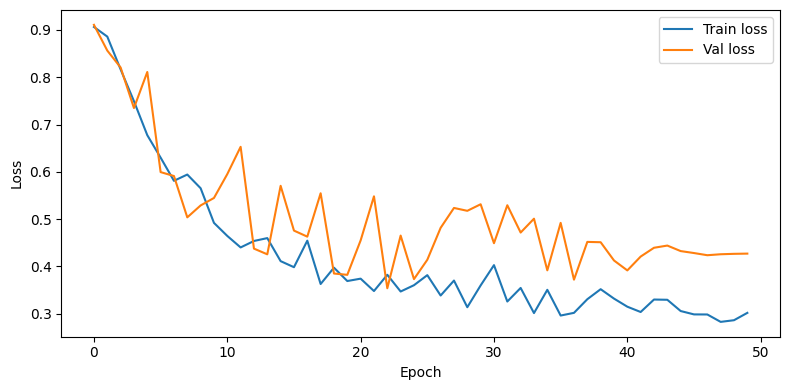

Best val loss: 0.3537 at epoch 23


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(all_train_losses, label='Train loss')
ax.plot(all_val_losses,   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Best val loss: {min(all_val_losses):.4f} at epoch {np.argmin(all_val_losses)+1}')

## 6. Evaluation on test set

In [9]:
checkpoint = torch.load(checkpoint_file)
model.load_state_dict(checkpoint['model'])
model.eval()

test_loader = DataLoader(
    Dataset(data=test_files, transform=val_transforms),
    batch_size=1, shuffle=False,
)

all_tp, all_fp, all_fn = 0, 0, 0
with torch.no_grad():
    for batch in test_loader:
        inp = batch['image'].cuda(non_blocking=True)
        tgt = batch['label'].cuda(non_blocking=True).float()
        roi = batch['roi'].cuda(non_blocking=True)
        logits = sliding_window_inference(
            inp, PATCH_SIZE, sw_batch_size=4, predictor=model, overlap=0.25,
        )
        logits = torch.where(roi.expand_as(logits) > 0, logits, torch.full_like(logits, -20.0))
        pred    = (torch.sigmoid(logits) > 0.5).float()
        all_tp += (pred * tgt).sum().item()
        all_fp += (pred * (1 - tgt)).sum().item()
        all_fn += ((1 - pred) * tgt).sum().item()

test_dice = 2*all_tp / (2*all_tp + all_fp + all_fn + 1e-8)
print(f'Test Dice : {test_dice:.4f}')
print(f'Best epoch: {checkpoint["epoch"]+1}  (val loss {min(all_val_losses):.4f})')

Test Dice : 0.5624
Best epoch: 23  (val loss 0.3537)


## 7. Visualization

Run inference on the full volume then inspect axial slices with a slider.

In [10]:
model.eval()

full_inp = torch.from_numpy(img_vol[None, None]).float().cuda()  # (1, 1, H, D, W)

with torch.no_grad():
    full_logits = sliding_window_inference(
        full_inp, PATCH_SIZE, sw_batch_size=4, predictor=model, overlap=0.25,
    )

pred_vol = (torch.sigmoid(full_logits).squeeze().cpu().numpy()  # (H, D, W)
            * roi_mask)                                           # zero outside ROI
print(f'pred_vol shape: {pred_vol.shape}')

pred_vol shape: (944, 180, 725)


In [11]:
import ipywidgets as widgets

def show(h):
    img   = img_vol[h, :, :]
    gt    = binary_seg[h, :, :]
    probs = pred_vol[h, :, :]
    pred  = probs > 0.5

    fn_mask = (gt == 1) & (pred == 0)
    tp_mask = (gt == 1) & (pred == 1)
    fp_mask = (gt == 0) & (pred == 1)

    split = ('TRAIN' if GOOD_START <= h < train_end
             else 'VAL' if train_end <= h < val_end
             else 'TEST' if val_end <= h < test_end
             else 'outside')

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'H={h}  [{split}]'); axes[0].axis('off')

    axes[1].imshow(img, cmap='gray')
    axes[1].imshow(np.where(fn_mask, 1, np.nan), cmap='Greens', alpha=0.9, vmin=0, vmax=1)
    axes[1].imshow(np.where(tp_mask, 1, np.nan), cmap='Blues',  alpha=0.9, vmin=0, vmax=1)
    axes[1].imshow(np.where(fp_mask, 1, np.nan), cmap='Reds',   alpha=0.9, vmin=0, vmax=1)
    n_tp = int(tp_mask.sum()); n_fp = int(fp_mask.sum()); n_fn = int(fn_mask.sum())
    d = 2*n_tp / (2*n_tp + n_fp + n_fn + 1e-8)
    axes[1].set_title(f'Dice:{d:.3f}  Green=FN  Blue=TP  Red=FP'); axes[1].axis('off')
    plt.tight_layout(); plt.show()

widgets.interact(show, h=widgets.IntSlider(min=GOOD_START, max=GOOD_END-1, step=1, value=(GOOD_START+GOOD_END)//2))

interactive(children=(IntSlider(value=470, description='h', max=839, min=101), Output()), _dom_classes=('widge…

<function __main__.show(h)>

Test Dice before SSFB : 0.4200

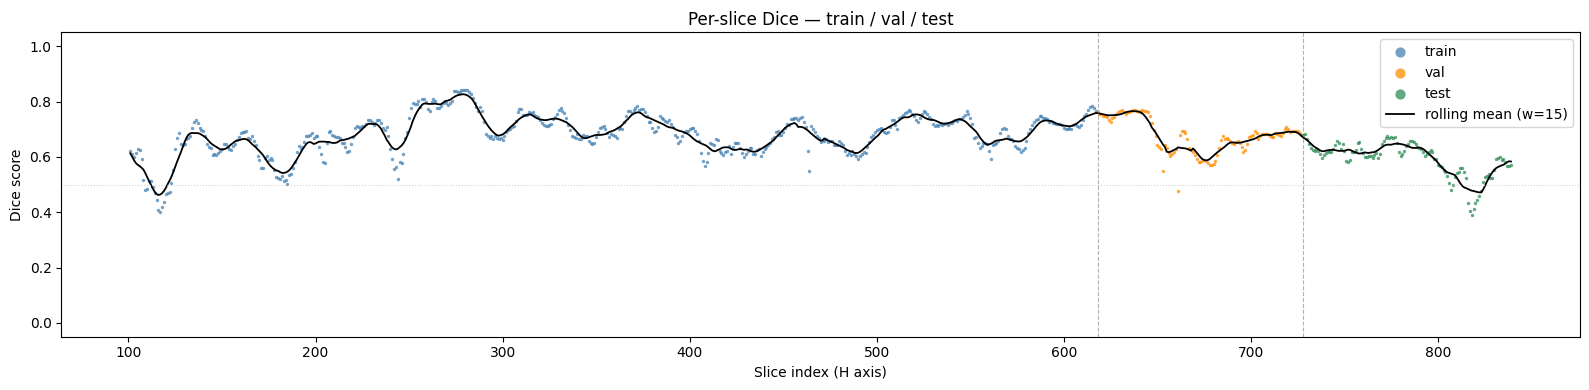

train  mean=0.6812  median=0.6872  min=0.4006  max=0.8417  n=517
val    mean=0.6771  median=0.6799  min=0.4784  max=0.7707  n=110
test   mean=0.5918  median=0.6081  min=0.3889  max=0.6836  n=112


In [12]:
# Per-slice Dice score — one dot per slice, coloured by split
THR = 0.5

# Compute Dice for every labelled slice
slice_dice = {}
for h in range(GOOD_START, GOOD_END):
    gt   = binary_seg[h] > 0.5       # (D, W) ground truth
    pred = pred_vol[h] > THR          # (D, W) binarised prediction
    tp = int((pred & gt).sum())
    fp = int((pred & ~gt).sum())
    fn = int((~pred & gt).sum())
    # NaN for slices where both gt and pred are empty (no annotation, no prediction)
    slice_dice[h] = 2*tp / (2*tp + fp + fn + 1e-8) if (gt.any() or pred.any()) else float('nan')

# Split boundaries (contiguous ranges set in cell [split])
splits = [
    (range(GOOD_START, train_end), 'steelblue',  'train'),
    (range(train_end,  val_end),   'darkorange', 'val'),
    (range(val_end,    test_end),  'seagreen',   'test'),
]

fig, ax = plt.subplots(figsize=(16, 4))

for rng, color, label in splits:
    xs = list(rng)
    ys = [slice_dice[h] for h in xs]
    ax.scatter(xs, ys, s=6, color=color, label=label, alpha=0.75, linewidths=0)

# Rolling mean (window = 15 slices)
all_hs = list(range(GOOD_START, GOOD_END))
all_ys = np.array([slice_dice[h] for h in all_hs])
w = 15
smooth = np.full_like(all_ys, np.nan)
for j in range(len(all_hs)):
    lo, hi = max(0, j - w//2), min(len(all_hs), j + w//2)
    vals = all_ys[lo:hi][~np.isnan(all_ys[lo:hi])]
    if len(vals):
        smooth[j] = vals.mean()
ax.plot(all_hs, smooth, color='black', linewidth=1.3, label=f'rolling mean (w={w})')

# Split boundary lines
ax.axvline(train_end, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(val_end,   color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(0.5, color='lightgray', linestyle=':', linewidth=0.8)

ax.set_xlabel('Slice index (H axis)')
ax.set_ylabel('Dice score')
ax.set_title('Per-slice Dice — train / val / test')
ax.set_ylim(-0.05, 1.05)
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

# Summary statistics per split
for rng, _, label in splits:
    ds = np.array([slice_dice[h] for h in rng])
    ds = ds[~np.isnan(ds)]
    if len(ds):
        print(f'{label:5s}  mean={ds.mean():.4f}  median={np.median(ds):.4f}  '
              f'min={ds.min():.4f}  max={ds.max():.4f}  n={len(ds)}')
